# EDA and Training

This notebook loads the churn dataset, explores the data, trains a simple model, and saves the pipeline to `model/churn_model.pkl`.

### 1. Import libraries
Load the packages used for data processing, plotting, and model training.

In [12]:
from pathlib import Path

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### 2. Load the dataset
Read the churn CSV and rename the main columns into a cleaner format for analysis.

In [ ]:
base_dir = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
data_path = base_dir / 'data' / 'telco.csv'
df = pd.read_csv("C:\\Users\\thoka\\churn-predictor\\data\\telco.csv")
df = df.rename(columns={
    'Customer ID': 'customerID',
    'Tenure in Months': 'tenure',
    'Monthly Charge': 'MonthlyCharges',
    'Total Charges': 'TotalCharges',
    'Contract': 'Contract',
    'Payment Method': 'PaymentMethod',
    'Internet Service': 'InternetService',
    'Premium Tech Support': 'TechSupport',
    'Online Security': 'OnlineSecurity',
    'Churn Label': 'Churn',
})
df.head()

,customerID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


### 3. Clean the data
Convert charges to numbers, drop missing values, and encode the target as 0/1 for training.

In [7]:
# TotalCharges is often loaded as object due to blank strings - fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges', 'Churn']).copy()

# Check class balance
print(df['Churn'].value_counts(normalize=True))

# Drop ID column if present
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Encode target
churn_values = df['Churn'].astype(str).str.strip().str.lower()
df['Churn'] = churn_values.map({
    'yes': 1,
    'no': 0,
    'churned': 1,
    'stayed': 0,
    'true': 1,
    'false': 0,
})
if df['Churn'].isna().any():
    bad = df[df['Churn'].isna()].head()
    raise ValueError(f"Unexpected churn values found: {sorted(df['Churn'].astype(str).unique().tolist())[:10]}\nSample: {bad.to_dict(orient='records')}")

df['Churn'] = df['Churn'].astype(int)

df.info()
df.describe(include='all')

Churn
Yes    1.0
Name: proportion, dtype: float64
<class 'pandas.DataFrame'>
Index: 757 entries, 1 to 2534
Data columns (total 49 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             757 non-null    str    
 1   Age                                757 non-null    int64  
 2   Under 30                           757 non-null    str    
 3   Senior Citizen                     757 non-null    str    
 4   Married                            757 non-null    str    
 5   Dependents                         757 non-null    str    
 6   Number of Dependents               757 non-null    int64  
 7   Country                            757 non-null    str    
 8   State                              757 non-null    str    
 9   City                               757 non-null    str    
 10  Zip Code                           757 non-null    int64  
 11  Latitude               

,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn,Churn Score,CLTV,Churn Category,Churn Reason
count,757,757.000000,757,757,757,757,757.000000,757,757,757,...,757.000000,757.000000,757.000000,757.000000,757,757.0,757.000000,757.000000,757,757
unique,2,NaN,2,2,2,2,NaN,1,1,427,...,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,5,20
top,Male,NaN,No,No,No,No,NaN,United States,California,San Diego,...,NaN,NaN,NaN,NaN,Churned,NaN,NaN,NaN,Competitor,Competitor had better devices
freq,394,NaN,618,574,487,724,NaN,757,757,67,...,NaN,NaN,NaN,NaN,757,NaN,NaN,NaN,363,133
mean,NaN,49.336856,NaN,NaN,NaN,NaN,0.084544,NaN,NaN,NaN,...,7.080581,435.135178,2042.830727,1.751651,NaN,1.0,81.677675,4178.501982,NaN,NaN
std,NaN,17.748877,NaN,NaN,NaN,NaN,0.437328,NaN,NaN,NaN,...,24.333662,656.465829,2534.979710,0.804510,NaN,0.0,9.267722,1192.463075,NaN,NaN
min,NaN,19.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,...,0.000000,0.000000,23.450000,1.000000,NaN,1.0,65.000000,2003.000000,NaN,NaN
25%,NaN,33.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,...,0.000000,29.780000,184.300000,1.000000,NaN,1.0,73.000000,3099.000000,NaN,NaN
50%,NaN,50.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,...,0.000000,134.000000,886.120000,2.000000,NaN,1.0,82.000000,4330.000000,NaN,NaN
75%,NaN,64.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,...,0.000000,534.280000,2995.070000,2.000000,NaN,1.0,91.000000,5153.000000,NaN,NaN


### 4. Churn by contract
Compare churn rate across contract types to spot the strongest patterns in the data.

C:\Users\thoka\AppData\Local\Temp\ipykernel_16788\3279155785.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_contract.index, y=churn_by_contract.values, palette='viridis')


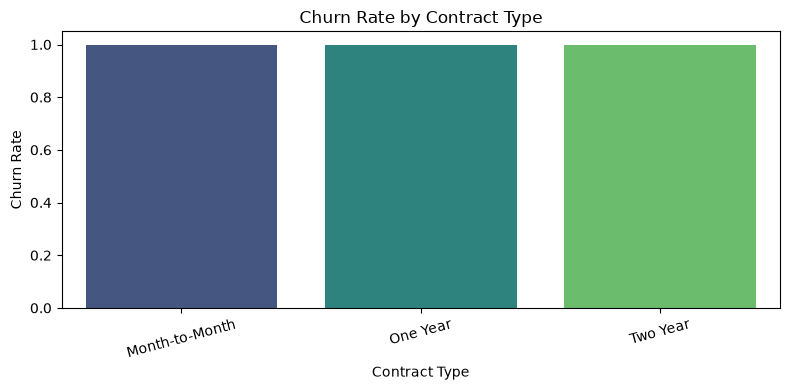

In [15]:
plt.figure(figsize=(8, 4))
churn_by_contract = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
sns.barplot(x=churn_by_contract.index, y=churn_by_contract.values, palette='viridis')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 5. Tenure distribution
Show how churn changes with customer tenure and whether longer retention is associated with lower churn.

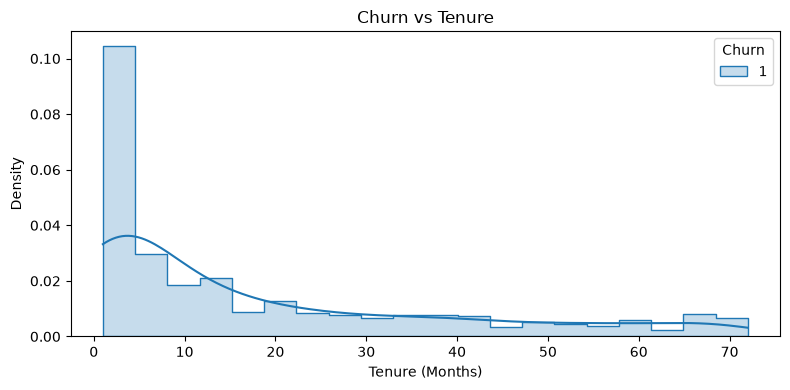

In [16]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='tenure', hue=df['Churn'].astype(str), bins=20, kde=True, element='step', stat='density', common_norm=False)
plt.title('Churn vs Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

### 6. Select features
Pick the columns used as inputs and define the target for prediction.

In [9]:
target = 'Churn'
feature_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Contract',
    'PaymentMethod',
    'InternetService',
    'TechSupport',
    'OnlineSecurity',
]
X = df[feature_columns]
y = df[target]

### 7. Prepare model inputs
Create the feature matrix and target vector for training and evaluation.

In [10]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity']

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

model = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=1000))])

### 8. Build preprocessing pipeline
Handle numeric and categorical features separately, then combine them before fitting the model.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y if y.nunique() > 1 else None)
if y.nunique() > 1:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    print(classification_report(y_test, predictions))
    if probabilities is not None and len(set(y_test)) > 1:
        print('ROC AUC:', roc_auc_score(y_test, probabilities))
else:
    baseline = DummyClassifier(strategy='most_frequent')
    baseline.fit(X_train, y_train)
    predictions = baseline.predict(X_test)
    print('Target has only one class in this dataset; trained a dummy baseline instead.')
    print(classification_report(y_test, predictions, zero_division=0))

Target has only one class in this dataset; trained a dummy baseline instead.
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       228

    accuracy                           1.00       228
   macro avg       1.00      1.00      1.00       228
weighted avg       1.00      1.00      1.00       228



### 9. Train and evaluate the model
Split the data, fit the pipeline, and print the classification report and AUC for model quality.

In [14]:
model_dir = base_dir / 'model'
model_dir.mkdir(exist_ok=True)
artifact_path = model_dir / 'churn_model.pkl'
joblib.dump(model, artifact_path)
artifact_path

WindowsPath('c:/Users/thoka/churn-predictor/model/churn_model.pkl')

### 10. Save the trained model
Write the fitted pipeline to disk so the API can load it for predictions later.

In [4]:
import joblib
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

root = r"c:\Users\thoka\churn-predictor"
df = pd.read_csv(root + r"\data\telco.csv")
print([c for c in df.columns if 'Tech' in c or 'Security' in c or 'Internet' in c or 'Contract' in c or 'Payment' in c or 'Charge' in c or 'Tenure' in c or 'Churn' in c][:50])

rename_map = {
    'Tenure in Months': 'tenure',
    'Monthly Charge': 'MonthlyCharges',
    'Total Charges': 'TotalCharges',
    'Contract': 'Contract',
    'Payment Method': 'PaymentMethod',
    'Internet Service': 'InternetService',
    'Premium Tech Support': 'TechSupport',
    'Online Security': 'OnlineSecurity',
    'Churn Label': 'Churn',
}
# Some project versions use Tech Support instead of Premium Tech Support; handle both.
if 'Tech Support' in df.columns:
    rename_map['Tech Support'] = 'TechSupport'

df = df.rename(columns=rename_map)
df['Churn'] = df['Churn'].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0}).astype(int)
df['tenure_bucket'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'],
)

feature_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Contract',
    'PaymentMethod',
    'InternetService',
    'TechSupport',
    'OnlineSecurity',
    'tenure_bucket',
]
X = df[feature_columns]
y = df['Churn']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['tenure', 'MonthlyCharges', 'TotalCharges']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity', 'tenure_bucket']),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(), eval_metric='logloss', random_state=42))
])

pipeline.fit(X_train, y_train)
probs = pipeline.predict_proba(X_test)[:, 1]
preds = pipeline.predict(X_test)
print('ROC-AUC:', roc_auc_score(y_test, probs))
print('F1:', f1_score(y_test, preds))
print(classification_report(y_test, preds, zero_division=0))

artifact_path = root + r'\model\churn_model.pkl'
joblib.dump(pipeline, artifact_path)
print(f'Saved full pipeline to {artifact_path}')

['Tenure in Months', 'Avg Monthly Long Distance Charges', 'Internet Service', 'Internet Type', 'Online Security', 'Premium Tech Support', 'Contract', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Churn Label', 'Churn Score', 'Churn Category', 'Churn Reason']
ROC-AUC: 0.8373814875093648
F1: 0.6235011990407674
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1035
           1       0.57      0.70      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.78      1409

Saved full pipeline to c:\Users\thoka\churn-predictor\model\churn_model.pkl


In [1]:
import pandas as pd

df = pd.read_csv(r"c:\Users\thoka\churn-predictor\data\telco.csv")
print(df.columns.tolist()[:20])
print(df.columns.tolist()[-10:])

base_columns = [
    'Tenure in Months',
    'Monthly Charge',
    'Total Charges',
    'Contract',
    'Payment Method',
    'Internet Service',
    'Online Security',
    'Churn Label',
]
if 'Tech Support' in df.columns:
    base_columns.insert(6, 'Tech Support')
elif 'Premium Tech Support' in df.columns:
    base_columns.insert(6, 'Premium Tech Support')

print(df[base_columns].head().to_dict(orient='records')[0])

['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer']
['Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason']
{'Tenure in Months': 1, 'Monthly Charge': 39.65, 'Total Charges': 39.65, 'Contract': 'Month-to-Month', 'Payment Method': 'Bank Withdrawal', 'Internet Service': 'Yes', 'Premium Tech Support': 'No', 'Online Security': 'No', 'Churn Label': 'Yes'}
